# 04 — HPO results (visualization)

Loads validation HPO artifacts from `models/nested_hpo/`.

Run training first:

```bash
python scripts/run_nested_hpo_gbm.py
# or
python scripts/run_pipeline.py
```

θ* is chosen on val (`2025-01-07` → `2025-06-24`) only. Test is evaluated in the final walk-forward (notebook 05).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from freight_rates.artifacts import require_hpo_artifacts
from freight_rates.evaluation import format_dual_regime_report
from freight_rates.hpo import select_best_config

ROOT = Path("..").resolve()
hpo = require_hpo_artifacts(ROOT / "models")
val_summary = hpo.val_summary
best_row, best_params, best_label = select_best_config(val_summary)
print("θ* =", best_params)
print(format_dual_regime_report(best_row.to_frame().T))

θ* = {'max_depth': 3, 'min_samples_leaf': 60, 'l2_regularization': 1.0, 'learning_rate': 0.08, 'max_iter': 200}
=== Dual-regime headline [cfg_05] ===
overall: n=1,997  MAE=0.0732  lag1=0.0739  lift=+0.0007  beats_lag1=True
cold 0-4: n=88  MAE=0.1624  lag1=0.1976  lift=+0.0352  beats_lag1=True


In [2]:
cols = [
    "label", "max_depth", "min_samples_leaf", "l2_regularization",
    "mae", "mae_lift", "cold_mae_lift", "beats_lag1_cold", "n", "cold_n",
]
ranked = val_summary[cols].sort_values(["beats_lag1_cold", "mae"], ascending=[False, True])
display(ranked)

,label,max_depth,min_samples_leaf,l2_regularization,mae,mae_lift,cold_mae_lift,beats_lag1_cold,n,cold_n
5,cfg_05,3,60,1.0,0.073159,0.000747,0.035174,True,1997,88
4,cfg_04,3,60,0.1,0.073179,0.000727,0.034681,True,1997,88
11,cfg_11,4,60,1.0,0.073480,0.000426,0.034556,True,1997,88
10,cfg_10,4,60,0.1,0.073494,0.000411,0.034070,True,1997,88
16,cfg_16,6,60,0.1,0.074073,-0.000167,0.032921,True,1997,88
17,cfg_17,6,60,1.0,0.074291,-0.000385,0.032014,True,1997,88
3,cfg_03,3,40,1.0,0.074594,-0.000689,0.012548,True,1997,88
2,cfg_02,3,40,0.1,0.074648,-0.000742,0.013227,True,1997,88
8,cfg_08,4,40,0.1,0.075281,-0.001375,0.011589,True,1997,88
9,cfg_09,4,40,1.0,0.075380,-0.001474,0.009958,True,1997,88


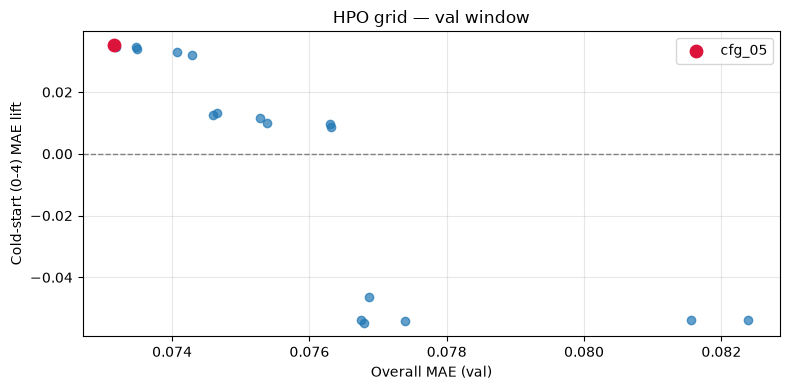

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(val_summary["mae"], val_summary["cold_mae_lift"], alpha=0.7)
best = val_summary.loc[val_summary["label"] == best_label].iloc[0]
ax.scatter(best["mae"], best["cold_mae_lift"], color="crimson", s=80, label=best_label, zorder=3)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Overall MAE (val)")
ax.set_ylabel("Cold-start (0-4) MAE lift")
ax.set_title("HPO grid — val window")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
display(hpo.val_folds_best)

,fold,date,n,mae,mae_baseline,mae_lift,medae,mape
0,1,2025-01-07,89,0.139129,0.139129,0.000000,0.000000,5.061016
1,2,2025-01-14,89,0.090236,0.105707,0.015471,0.000000,2.861833
2,3,2025-01-21,79,0.056905,0.052503,-0.004402,0.000000,2.007757
3,4,2025-01-28,79,0.143618,0.146340,0.002722,0.000000,5.266419
4,5,2025-02-04,79,0.057979,0.054484,-0.003495,0.000000,2.142340
5,6,2025-02-11,78,0.117570,0.121551,0.003981,0.040325,3.938255
6,7,2025-02-18,77,0.091857,0.087342,-0.004515,0.000000,3.728649
7,8,2025-02-25,78,0.051612,0.053390,0.001778,0.000000,2.025428
8,9,2025-03-04,80,0.045329,0.054398,0.009069,0.000000,2.203274
9,10,2025-03-11,82,0.080194,0.076745,-0.003449,0.000000,3.088579
